In [81]:
# Import necessary packages

import os
import glob
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
import logging

import tifffile as tiff
import numpy as np
import matplotlib.pyplot as plt
import plotnine as p9
import pandas as pd
from skimage import feature, io
from scipy.stats import norm
from scipy.ndimage import label, find_objects

# Make path for scripts relative to the working directory
sys.path.insert(0, '../src')  # Adjust the path as needed

# Setup basic logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [95]:
# Define path names and load some basic functions for reading in files

# Define the location of the file to read
parent_directory = "/Users/nestor/Documents/NYU-ISG/microscope-data" # modify if needed
experiment = "03182024_IF-FISH_test2" # this will be changed for each experiment

# Read in the experimental groups reference file
exp_groups = pd.read_csv(os.path.join(parent_directory, experiment, "experimental-groups.csv"))

# Load the function img_loadr() 
from load_files import img_loadr

def extract_base_name(filename):
    """
    Extract the base name from the file name without removing important parts of the name,
    such as the date and experiment information, while stripping the channel prefixes from masks.
    """
    name = os.path.basename(filename)

    # Only remove 'C1-', 'C2-', etc., from mask files
    if name.startswith(("C1-", "C2-", "C3-", "C4-", "C5-")):
        name = name[3:]  # Remove the first 3 characters (e.g., 'C1-', 'C2-', etc)
    
    # Remove the "_cp_masks" suffix for masks or ".ome" from image files if present
    name = name.replace("_cp_masks", "").replace(".ome", "")
    
    # Remove the file extension
    base_name = os.path.splitext(name)[0]
    
    return base_name

In [97]:
# CHUNK 1 # 
# Load maximum intensity projection (MIP) files
# and segmentation masks for images in one experiment

# This dictionary defines the folders inside of "experiment" that contain each image type
file_folders = {
    "image": "MIPs/MIPs_multichannel/", 
    "mask_n": "segmentation-masks/nuclei_masks/"
}

# These dictionaries will store all image files, their file names and the base name:
all_images = {"image": [], "mask_n": []}
file_names = {"image": [], "mask_n": []}
base_names = {"image": [], "mask_n": []}  # Store base names for images and masks
errors = []  # List to store error messages


# Load files with parallel processing using img_loadr() from load_files.py
with ThreadPoolExecutor(max_workers=4) as executor:  # Adjust the number of workers as needed
    for f in file_folders:
        # Build the path to the folders indicated at the top
        file_path = os.path.join(parent_directory, experiment, file_folders[f])
        files = glob.glob(os.path.join(file_path, "*.tif"))
        # Run load_image() over the list of files in the folder (files, just above)
        results = executor.map(img_loadr, files)

        for result in results:
            # Unpack the tuples in results, and save the image in all_images[] 
            # and the file names in file_names[]
            image, filename = result
            if image is not None:
                all_images[f].append(image)
                file_names[f].append(filename)
                base_names[f].append(extract_base_name(filename))  # Store the base name

# Log the completion of image processing
if errors:
    logging.error(f"Completed with errors in {len(errors)} files.")
else:
    logging.info("All images and masks have been processed successfully without errors.")

# Optional: Summary of processed files
logging.info(f"Processed {len(file_names['image'])} images and {len(file_names['mask_n'])} nuclei masks.")

# Now, all_images["image"] contains all the images (MIPs), 
# all_images["mask_n"] contains all the nuclei masks and 
# all_images["mask_b"] contains all the background masks

2024-10-17 10:13:46,687 - INFO - All images and masks have been processed successfully without errors.
2024-10-17 10:13:46,688 - INFO - Processed 12 images and 12 nuclei masks.


In [99]:
# Print the base names for debugging purposes
print("Image Base Names:", base_names['image'])
print("Mask Base Names:", base_names['mask_n'])

Image Base Names: ['03182024_IF-FISH_fullFinn_2_MMStack_Pos3_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos0_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos1_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos3_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP', '03182024_IF-FISH_fullFinn_1_MMStack_Pos1_MIP', '03182024_IF-FISH_fullFinn_2_MMStack_Pos4_MIP', '03182024_IF-FISH_fullFinn_1_MMStack_Pos0_MIP', '03182024_IF-FISH_fullFinn_2_MMStack_Pos5_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos4_MIP', '03182024_IF-FISH_fullFinn_1_MMStack_Pos2_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos5_MIP']
Mask Base Names: ['03182024_IF-FISH_fullFinn_3_MMStack_Pos2_MIP', '03182024_IF-FISH_fullFinn_2_MMStack_Pos3_MIP', '03182024_IF-FISH_fullFinn_1_MMStack_Pos0_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos3_MIP', '03182024_IF-FISH_fullFinn_1_MMStack_Pos1_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos0_MIP', '03182024_IF-FISH_fullFinn_3_MMStack_Pos4_MIP', '03182024_IF-FISH_fullFinn_2_MMStack_Pos5_MIP', '03

In [101]:
# Check dimensions of a given set of images, to verify they're correct

# Define function to check dimensions of images and masks
def img_sizr(image_types, file_indices):
    for f in file_indices:
        for image_type in image_types:
            try:
                image_shape = all_images[image_type][f].shape
                logging.info(f"File {f} ({image_type}): {image_shape}")
            except IndexError:
                logging.warning(f"File index {f} for {image_type} is out of range.")
            except KeyError:
                logging.error(f"Image type {image_type} does not exist.")

# Define the list of image types to check
image_types_to_check = ['image', 'mask_n']  # Add 'mask_b' if you want to check background masks too

# And the list of file indices to check
test_files = [10, 5]

# Run the check
img_sizr(image_types_to_check, test_files)

2024-10-17 10:13:50,873 - INFO - File 10 (image): (3, 2048, 2048)
2024-10-17 10:13:50,877 - INFO - File 10 (mask_n): (2048, 2048)
2024-10-17 10:13:50,880 - INFO - File 5 (image): (3, 2048, 2048)
2024-10-17 10:13:50,881 - INFO - File 5 (mask_n): (2048, 2048)


In [103]:
# CHUNK 2 #
# Match image indices to mask indices, to make sure they're paired correctly
# as they may not have been read in the same order

# Assuming base_names['image'] and base_names['mask_n'] contain the base names
image_base_names = base_names['image']
mask_base_names = base_names['mask_n']

# Convert list of mask base names to a dictionary for faster lookup
mask_name_to_index = {base_name: idx for idx, base_name in enumerate(mask_base_names)}

# Match each image with its corresponding mask using base names
matched_indices = []
missing_masks = 0
for img_index, img_base_name in enumerate(image_base_names):
    mask_index = mask_name_to_index.get(img_base_name)

    if mask_index is not None:
        matched_indices.append((img_index, mask_index))
    else:
        missing_masks += 1
        logging.warning(f"No matching mask found for image: {file_names['image'][img_index]}")

# Log the results of the matching
logging.info(f"Matched {len(matched_indices)} images with masks. Missing masks for {missing_masks} images.")

# Now, matched_indices contains pairs of indices for matched image and mask

2024-10-17 10:13:53,427 - INFO - Matched 12 images with masks. Missing masks for 0 images.


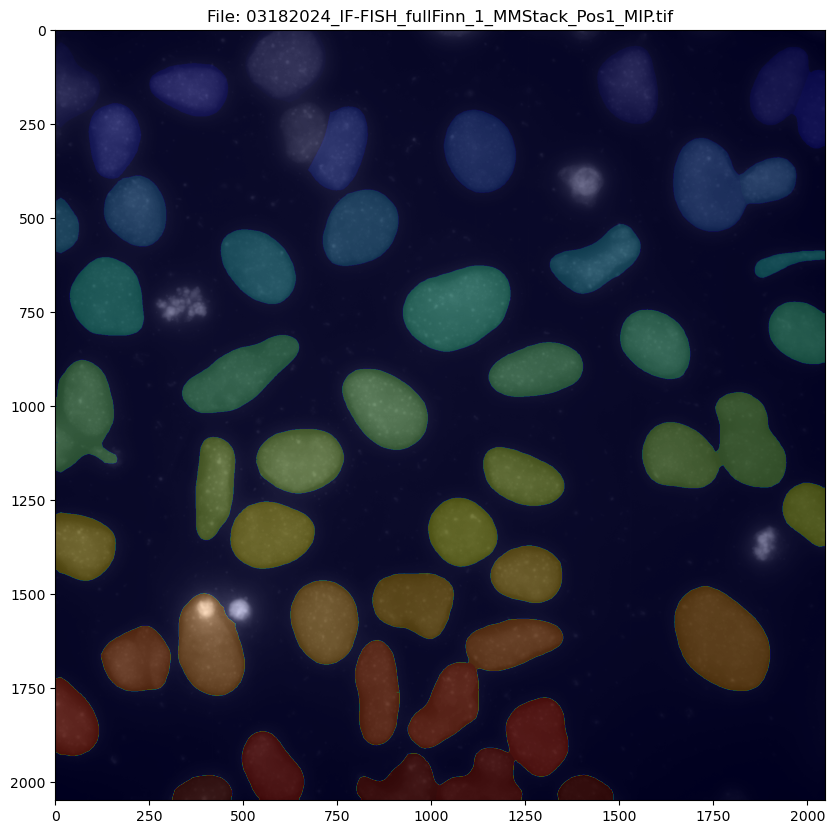

In [105]:
# Overlay the corresponding mask on a channel (given as c) of a given image
# to visually inspect

# Specify the index of the image to check
# and the channel to plot — remember CH1 for ImageJ but channel 0 for Python!
image_index = 5 # Replace with the desired index
c = 0 # remember the channel order in these images

# Find the corresponding mask index
# and define the image and mask pair
mask_index = [pair[1] for pair in matched_indices if pair[0] == image_index][0]

my_image = all_images['image'][image_index]
image_file = file_names['image'][image_index]
my_mask_n = all_images['mask_n'][mask_index]

# Select the c channel
channel_image = my_image[c, ...]

# Overlay the mask on the rest of the image if they have the same dimensions
if channel_image.shape != my_mask_n.shape:
    print("Warning: The image and mask sizes do not match. Please check your data.")
else:
    overlay = np.ma.masked_where(my_mask_n == 0, my_mask_n)
    plt.figure(figsize=(10, 10))
    plt.imshow(channel_image, cmap='gray')  # Display the selected channel in grayscale
    plt.imshow(my_mask_n, cmap='jet', alpha=0.25)  # Overlay the mask with transparency
    plt.title(f'File: {image_file}')
    #plt.axis('off')  # Turn off axis labels
    plt.show()

In [13]:
# CHUNK 3 (optional) # 
# Background analysis

# Define a function that identifies all potential background regions (ROI = 0)
def find_background_regions(nuclear_mask):
    """
    Identifies and labels distinct background regions (where ROI == 0) in a nuclear mask.

    Parameters:
    - nuclear_mask: numpy array representing the nuclear mask, where 0 denotes background.

    Returns:
    - labeled_background: numpy array with the same shape as nuclear_mask, where each
                          distinct background region is labeled with a unique integer,
                          and non-background areas are labeled as 0.
    """
    # Create a binary array where True denotes background
    background = (nuclear_mask == 0)

    # Use scipy.ndimage.label to label connected components in the background
    labeled_background, num_features = label(background)

    # The function labels all connected components. We will zero out non-background regions
    # which have been inadvertently labeled by reversing the initial condition.
    labeled_background[nuclear_mask != 0] = 0

    return labeled_background, num_features

In [15]:
# Initialize storage for the labeled backgrounds, region counts, and additional metrics
labeled_backgrounds = []
background_region_deets = []

# For each of the masks, find the background regions 
# and obtain their area and average intensity on each channel
for mask_index, nuclear_mask in enumerate(all_images['mask_n']):
    labeled_bg, num_features = find_background_regions(nuclear_mask)
    labeled_backgrounds.append(labeled_bg)
    region_details = []

    # Fetch the corresponding image for intensity calculations
    corresponding_image = all_images['image'][mask_index]

    # Process each background region
    for region_label in range(1, num_features + 1):
        region_mask = (labeled_bg == region_label)
        region_area = np.sum(region_mask)
        region_avg_intensities = []
        region_median_intensities = []

        # Calculate average and median intensity per channel within the region
        for channel_index in range(corresponding_image.shape[0]):
            channel_data = corresponding_image[channel_index]
            avg_intensity = np.mean(channel_data[region_mask])
            median_intensity = np.median(channel_data[region_mask])
            region_avg_intensities.append(avg_intensity)
            region_median_intensities.append(median_intensity)

        # Store details for the current region
        region_details.append({
            'area': region_area,
            'avg_intensities': region_avg_intensities,
            'median_intensities': region_median_intensities 
        })

    # Store details for all regions in the current mask
    background_region_deets.append(region_details)

# Now you have labeled_backgrounds storing all the labeled background masks
# and background_region_counts storing the count of regions for each mask

In [17]:
# Flatten the data structure into a list of dictionaries
data_for_df = []
for mask_index, regions in enumerate(background_region_deets):
    mask_filename = file_names['mask_n'][mask_index]  # Get the filename using the mask_index
    for region_index, details in enumerate(regions):
        # Create a dictionary for each region that includes mask index, region index, and mask filename
        region_dict = {
            'mask_index': mask_index,
            'region_index': region_index + 1,  # Add 1 to make it 1-based index
            'mask_filename': mask_filename,  # Include the filename of the mask
            'area': details['area']
        }
        
        # Add average intensities for each channel
        for channel_index, avg_intensity in enumerate(details['avg_intensities']):
            region_dict[f'avg_intensity_channel_{channel_index}'] = avg_intensity

        # Add median intensities for each channel
        for channel_index, median_intensity in enumerate(details['median_intensities']):
            region_dict[f'median_intensity_channel_{channel_index}'] = median_intensity

        
        data_for_df.append(region_dict)

# Create a DataFrame from the list of dictionaries
bk_df = pd.DataFrame(data_for_df)
print(bk_df.head())

   mask_index  region_index  \
0           0             1   
1           0             2   
2           0             3   
3           0             4   
4           0             5   

                                       mask_filename     area  \
0  C1-09042024_Cen-ZF_NT-GFP_Cen4-ZF1c_1_MMStack_...  3371021   
1  C1-09042024_Cen-ZF_NT-GFP_Cen4-ZF1c_1_MMStack_...        6   
2  C1-09042024_Cen-ZF_NT-GFP_Cen4-ZF1c_1_MMStack_...        1   
3  C1-09042024_Cen-ZF_NT-GFP_Cen4-ZF1c_1_MMStack_...        5   
4  C1-09042024_Cen-ZF_NT-GFP_Cen4-ZF1c_1_MMStack_...        5   

   avg_intensity_channel_0  avg_intensity_channel_1  \
0              2239.506949               513.102663   
1              1382.833333               271.166667   
2              1750.000000               287.000000   
3              1556.400000               315.000000   
4              1358.200000               803.200000   

   median_intensity_channel_0  median_intensity_channel_1  
0                      1196.0  

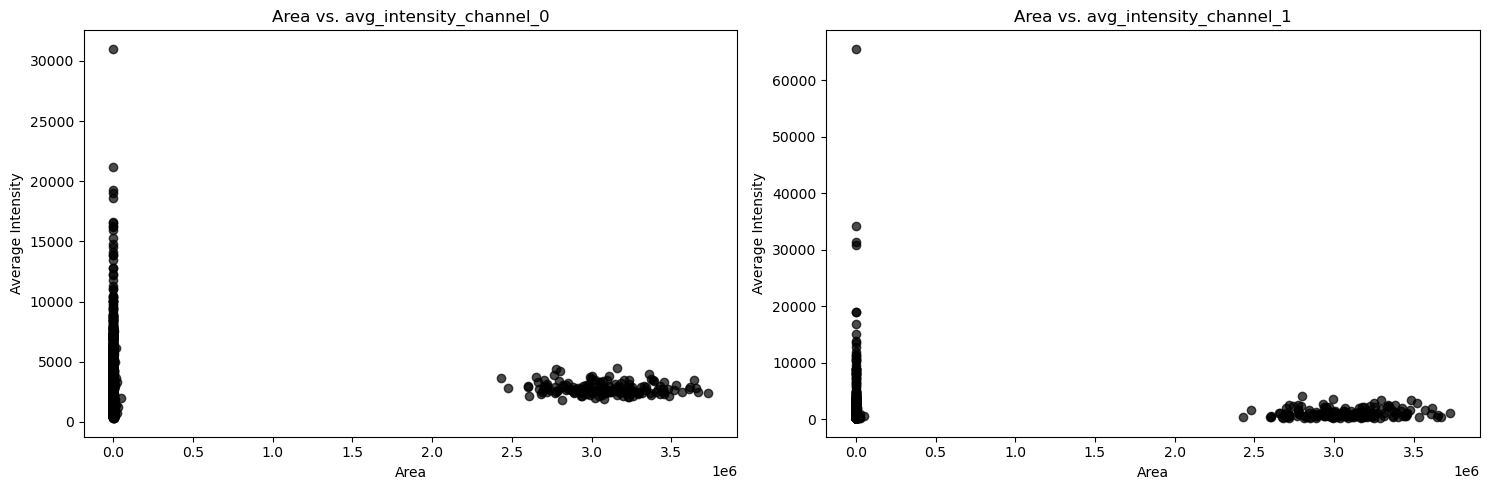

In [19]:
# Determine the number of channels from the DataFrame column names
channel_columns = [col for col in bk_df.columns if 'avg_intensity_channel_' in col]
num_channels = len(channel_columns)

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx, channel in enumerate(channel_columns):
    ax = axes[idx]
    ax.scatter(bk_df['area'], bk_df[channel], color='black', alpha=0.7)
    ax.set_title(f'Area vs. {channel}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Average Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

The background objects fall clearly into two categories, one with large objects that have low intensity values (the true background) and one with small objects of varying intensity levels (some as high as the nuclei, the true signal). If we do background subtraction, we should only use the large objects, with low intensity values

In [201]:
# CHUNK 3 (cont) #
# Incorporate the same operations ran above into a single step that extracts the largest background ROI
# and calculates the corresponding intensities

from background_subtraction import get_largest_background

# Initialize a list to store background values
bk_values = []

# Use the matched indices to correctly process each image and its corresponding mask
for img_index, mask_index in matched_indices:
    image = all_images['image'][img_index]  # Get the correct image by image index
    mask = all_images['mask_n'][mask_index]  # Get the corresponding mask by mask index

    # Get background data for the current image-mask pair
    result = get_largest_background(mask, image, img_index)
    area = result['area']
    
    # Collect data for each channel from the background analysis
    for channel, (avg_intensity, median_intensity) in enumerate(zip(result['average_intensities'], result['median_intensities'])):
        bk_values.append({
            'image_index': img_index,  # Store image index to track which image this data belongs to
            'mask_index': mask_index,  # Also store mask index for completeness
            'channel': channel,
            'avg_intensity': avg_intensity,
            'median_intensity': median_intensity,
            'area': area
        })

# Convert the list of formatted dictionaries to a DataFrame
bk_df = pd.DataFrame(bk_values)
print(bk_df.head())

   image_index  mask_index  channel  avg_intensity  median_intensity     area
0            0         157        0    1910.935340            1232.0  3650656
1            0         157        1     632.595381             354.0  3650656
2            1          51        0    1886.206224            1384.0  3112661
3            1          51        1     933.268017             549.0  3112661
4            2          78        0    2050.341185            1760.0  2765282


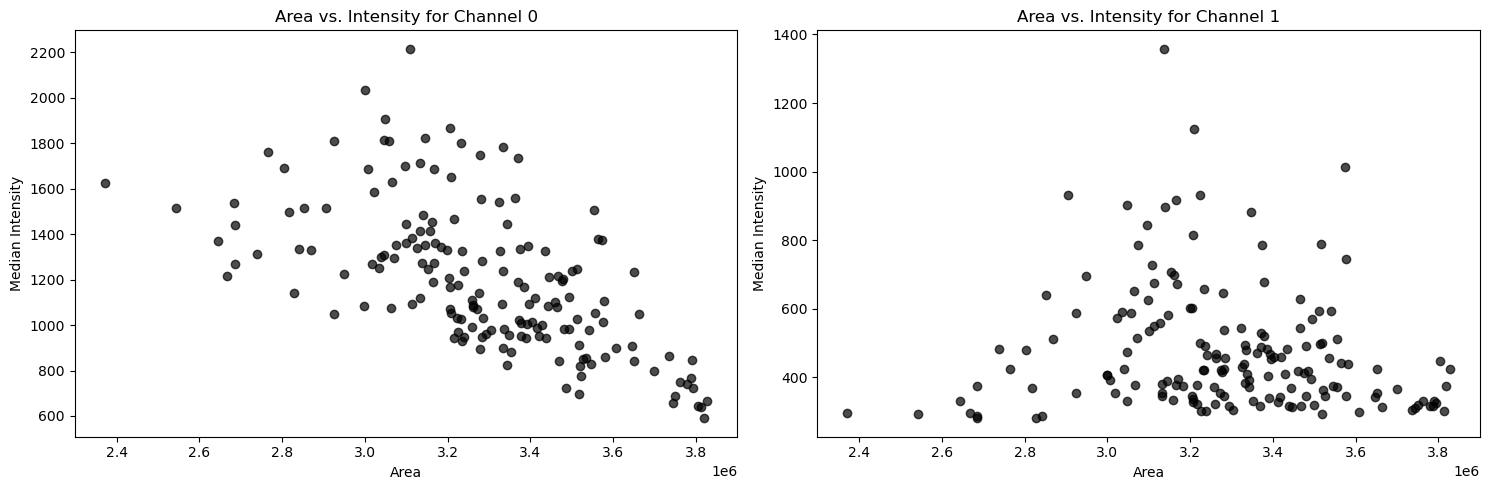

In [203]:
# Plot area vs  intensity for each channel for the true background only

# Determine the number of channels from the DataFrame column names
# Determine the number of channels from the DataFrame by examining the unique values in the 'channel' column
num_channels = bk_df['channel'].max() + 1  # Assuming channel numbers start from 0

# Set up the figure with subplots arranged side by side
fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))  # Adjust total width and height as needed

if num_channels == 1:  # If there's only one channel, make sure 'axes' is iterable
    axes = [axes]

# Plot each channel's intensity against the area
for idx in range(num_channels):
    current_df = bk_df[bk_df['channel'] == idx]
    ax = axes[idx]
    ax.scatter(current_df['area'], current_df['median_intensity'], color='black', alpha=0.7)
    ax.set_title(f'Area vs. Intensity for Channel {idx}')
    ax.set_xlabel('Area')
    ax.set_ylabel('Median Intensity')

# Ensure the layout is organized to prevent overlap of plot elements
plt.tight_layout()
plt.show()

In [205]:
# CHUNK 4 #

# Extract a set of metrics for each ROI in the image-mask pair
# using the measureROIs() function

from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare to store ROI metrics
all_roi_metrics = {}

# Function to process each image and mask pair
def process_image_data(task):
    img_index, mask_index = task
    image = all_images['image'][img_index]
    mask = all_images['mask_n'][mask_index]
    return measureROIs((img_index, image, mask), subtract_background = False)

# Execute processing in parallel
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks based on matched indices
        tasks = matched_indices
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            img_index, roi_metrics = result
            all_roi_metrics[f'Image {img_index}'] = roi_metrics
            
    logging.info("Metrics extraction complete for all ROIs across all matched images, no background subtraction.")

2024-10-11 11:39:32,809 - INFO - Metrics extraction complete for all ROIs across all matched images, no background subtraction.


In [207]:
# CHUNK 4.2 #

# Do the same as above, but doing background subtraction

from get_roi_metrics import measureROIs

# Set up logging for debugging and progress tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Prepare to store ROI metrics
bs_roi_metrics = {}

# Function to process each image and mask pair
def process_image_data(task):
    img_index, mask_index = task
    image = all_images['image'][img_index]
    mask = all_images['mask_n'][mask_index]
    return measureROIs((img_index, image, mask), subtract_background = True)

# Execute processing in parallel
if __name__ == '__main__':
    with ThreadPoolExecutor(max_workers=4) as executor:
        # Create tasks based on matched indices
        tasks = matched_indices
        results = list(executor.map(process_image_data, tasks))

        # Store the results in the dictionary
        for result in results:
            img_index, roi_metrics = result
            bs_roi_metrics[f'Image {img_index}'] = roi_metrics
            
    logging.info("Metrics extraction complete for all ROIs across all matched images, with background subtraction.")

2024-10-11 11:40:07,062 - INFO - Metrics extraction complete for all ROIs across all matched images, with background subtraction.


In [209]:
# CHUNK 5 #

# Turn the all_roi_metrics and the bs_roi_metrics dictionaries into Pandas data frames for easier manipulation

# List to hold each row's data
data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for image_key, rois in all_roi_metrics.items():
    image_index = int(image_key.split()[1])  # Extract image index
    file_name = image_file_names[image_index]  # Get the file name from image_file_names list
    
    for roi_key, channels in rois.items():
        for channel_key, metrics in channels.items():
            # Create a dictionary for each row of data 
            # including image, roi, channel, and metrics
            row_data = {
                "image_index": image_index,
                "filename": file_name,
                "experiment": experiment,
                "ROI_index": roi_key,
                "channel": int(channel_key.split()[1])  # Convert 'Channel X' to integer X
            }
            row_data.update(metrics)  # Add the metrics to the row

            # Append each row_data dictionary to the data_rows list
            data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metrics_df = pd.DataFrame(data_rows)

data_rows = []

# Iterate through each level of the nested dictionary to extract data
# for each channel of each ROI in each image
for image_key, rois in bs_roi_metrics.items():
    image_index = int(image_key.split()[1])  # Extract image index
    file_name = image_file_names[image_index]  # Get the file name from image_file_names list
    
    for roi_key, channels in rois.items():
        for channel_key, metrics in channels.items():
            # Create a dictionary for each row of data 
            # including image, roi, channel, and metrics
            row_data = {
                "image_index": image_index,
                "filename": file_name,
                "experiment": experiment,
                "ROI_index": roi_key,
                "channel": int(channel_key.split()[1])  # Convert 'Channel X' to integer X
            }
            row_data.update(metrics)  # Add the metrics to the row

            # Append each row_data dictionary to the data_rows list
            data_rows.append(row_data)

# Convert the list of dictionaries to a DataFrame
metricsBS_df = pd.DataFrame(data_rows)

In [33]:
# Display the first few rows of the DataFrame to verify it's correct
print(metrics_df.head())

   image_index                                           filename  \
0            0  09042024_Cen-ZF_NT-GFP_Cen3-ZF1b_1_MMStack_Pos...   
1            0  09042024_Cen-ZF_NT-GFP_Cen3-ZF1b_1_MMStack_Pos...   
2            0  09042024_Cen-ZF_NT-GFP_Cen3-ZF1b_1_MMStack_Pos...   
3            0  09042024_Cen-ZF_NT-GFP_Cen3-ZF1b_1_MMStack_Pos...   
4            0  09042024_Cen-ZF_NT-GFP_Cen3-ZF1b_1_MMStack_Pos...   

                      experiment  ROI_index  channel   area          avg  \
0  09042024_Cen-ZF_set3_session1          1        0  21663  3692.409639   
1  09042024_Cen-ZF_set3_session1          1        1  21663   287.661173   
2  09042024_Cen-ZF_set3_session1          2        0  30786  2983.232703   
3  09042024_Cen-ZF_set3_session1          2        1  30786   239.247678   
4  09042024_Cen-ZF_set3_session1          3        0  27046  3087.568846   

   median         std  maxima  minima  
0  3786.0  756.601776    5519    1487  
1   283.0   26.443456     429     218  
2  3028.

In [35]:
print(bk_df.head())

   image_index  mask_index  channel  avg_intensity  median_intensity     area
0            0         136        0    1213.862659             982.0  3042927
1            0         136        1     529.580016             336.0  3042927
2            1         124        0    2186.983130            1521.0  2958018
3            1         124        1    1062.367228             562.0  2958018
4            2          36        0    1237.527315             807.0  3669758


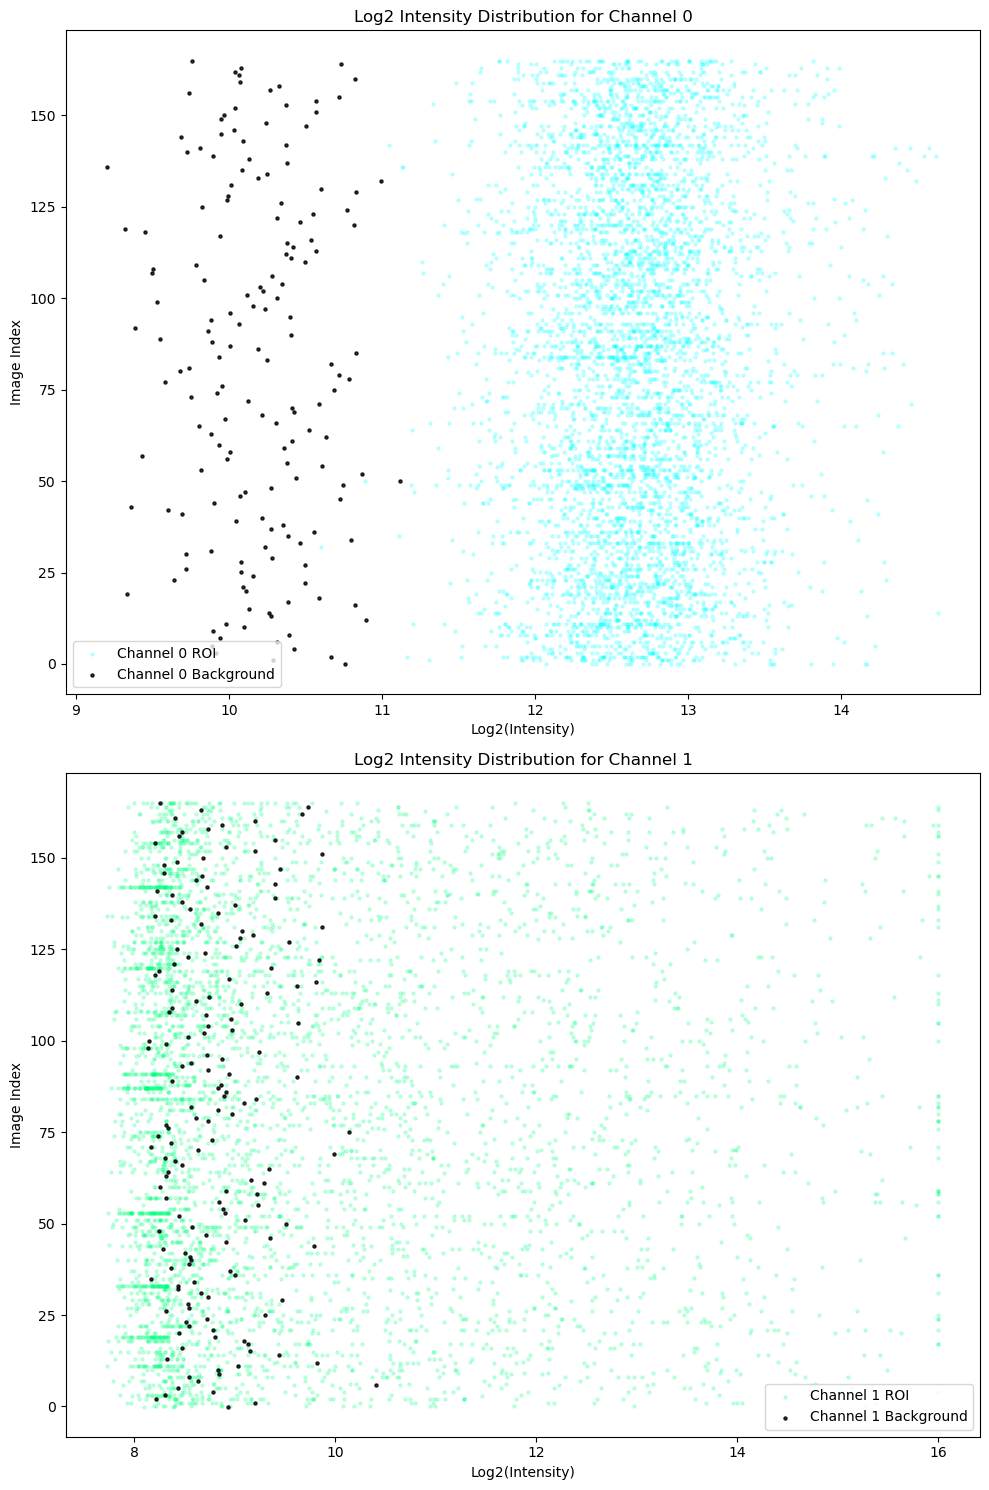

In [211]:
# Plot the background values over the nuclear values to assess if they are in the expected range:

# Define the colors for each channel
# channel_colors = {0: 'cyan', 1: 'springgreen', 2: 'magenta'}
channel_colors = {0: 'cyan', 1: 'springgreen'}

# Setup the figure
fig, ax = plt.subplots(2, 1, figsize=(10, 15))  # Wide plot

def add_jitter(values, jitter_strength=0.03):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(values))
    return values + jitter

# Plot data for each channel
for channel, ax in enumerate(ax):
    # Get data for the current channel
    # ROI data
    roi_data = metrics_df[metrics_df['channel'] == channel]
    roi_log2_data = np.log2(roi_data['median'] + 1)  # Log2 transform
    roi_image_indices = add_jitter(roi_data['image_index'])  # Add jitter to image index

    # Background data
    bk_data = bk_df[bk_df['channel'] == channel]
    bk_log2_data = np.log2(bk_data['median_intensity'] + 1)  # Log2 transform
    bk_image_indices = add_jitter(bk_data['mask_index'])  # Add jitter to image index


    # Scatter plots
    # Plot ROI data
    ax.scatter(roi_log2_data, roi_image_indices, 
               color=channel_colors[channel], 
               s=5,
               alpha=0.2, 
               label=f'Channel {channel} ROI')
    # Plot Background data
    ax.scatter(bk_log2_data, bk_image_indices, 
               color='black', 
               s=5,
               alpha=0.8, 
               label=f'Channel {channel} Background')

    # Set titles and labels
    ax.set_title(f'Log2 Intensity Distribution for Channel {channel}')
    ax.set_xlabel('Log2(Intensity)')
    ax.set_ylabel('Image Index')
    ax.legend()

# Adjust layout
plt.tight_layout()
plt.show()

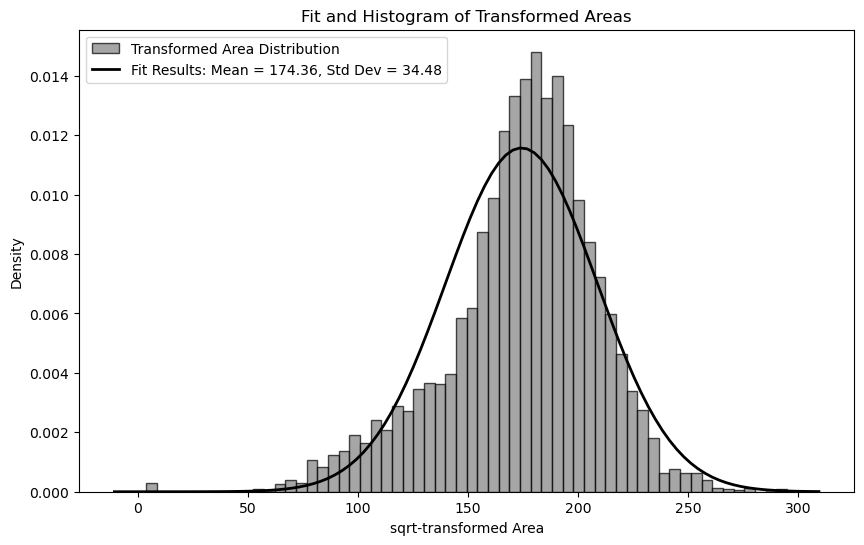

In [213]:
# Plot the distribution of ROI areas in the raw data

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Define the directory to save the plot
plot_dir = os.path.join(parent_directory, experiment, "py-plots/outlier_removal")
os.makedirs(plot_dir, exist_ok = True)

# Collect all ROI areas directly from the DataFrame
all_areas = metrics_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_original.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [215]:
# CHUNK 6 # 

# Remove values outside the number of SD that the user defines 
# for the log or sqrt-transformed data, as above
# (2*SD seems generally reasonable for this data)
# using the outliersOut function found in outliers_removal.py

from outliers_removal import outliersOut

sd_cutoff = 2
tx = "sqrt"

filtr_metrics_df, thresholds = outliersOut(metrics_df, sd_filter = sd_cutoff, transformation = tx)

# Print the thresholds to verify them
print("Calculated thresholds:")
print(f"Mean: {thresholds[0]}, Std Dev: {thresholds[1]}")
print(f"Lower Threshold: {thresholds[2]}, Upper Threshold: {thresholds[3]}")

# Optionally, display some of the filtered data to inspect the results
# print(filtr_metrics_df.head())

Calculated thresholds:
Mean: 174.35587451704953, Std Dev: 34.48493559024955
Lower Threshold: 105.38600333655043, Upper Threshold: 243.32574569754863


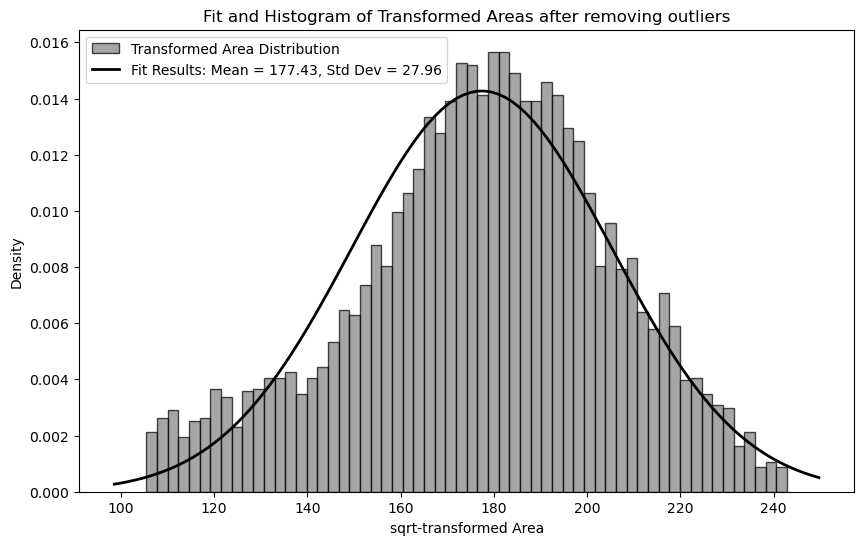

In [217]:
# Plot the distribution of ROI areas in the filtered data

# Set the transformation (log or sqrt) of the data you want to visualize
tx = 'sqrt'

# Define the directory to save the plot
plot_dir = os.path.join(parent_directory, experiment, "py-plots/outlier_removal")
os.makedirs(plot_dir, exist_ok = True)

# Collect all ROI areas directly from the DataFrame
all_areas = filtr_metrics_df['area'].values

# Apply the transformation (log or sqrt)
if tx == 'log':
    tx_areas = np.log(all_areas + 1)  # Added 1 to avoid log(0)
elif tx == 'sqrt':
    tx_areas = np.sqrt(all_areas)
else:
    raise ValueError("Transformation should be either 'log' or 'sqrt'.")

# Fit a normal distribution to the transformed areas
mean, std_dev = norm.fit(tx_areas)

# Generate histogram of the transformed areas
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(tx_areas, 
                            bins=60, 
                            color='gray', 
                            edgecolor='black', 
                            linewidth=1, 
                            alpha=0.7, 
                            label='Transformed Area Distribution', 
                            density=True)
plt.xlabel(f'{tx}-transformed Area')
plt.ylabel('Density')

# Generate the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std_dev)
plt.plot(x, p, 'k', linewidth=2, label=f'Fit Results: Mean = {mean:.2f}, Std Dev = {std_dev:.2f}')
plt.title('Fit and Histogram of Transformed Areas after removing outliers')
plt.legend()

# Save the plot to disk as a .png file
plot_filename = 'area_distr_no-outliers.png'  # Replace with your desired file name
plt.savefig(f"{plot_dir}/{plot_filename}", format='png')  # Change format to 'tif' if needed

# Show the plot on the console
plt.show()

plt.close()  # Close the plot to free memory

In [219]:
# Replace these with the indices of the image, ROI, and channel you want to inspect
image_index = 5  # First image
roi_index = 9   # ROI with ID 9
channel_index = 0  # First channel

image_file = image_file_names[image_index]
image_key = f"Image {image_index}"
roi_metrics = all_roi_metrics.get(image_key, {})
roi_channel_metrics = roi_metrics.get(roi_index, {}).get(f'Channel {channel_index}', {})

print(f"Metrics for Image {image_index}, ({image_file}), ROI {roi_index}, Channel {channel_index}:")
for metric, value in roi_channel_metrics.items():
    print(f"  {metric}: {value:.2f}")

Metrics for Image 5, (09092024_Cen-ZF_NT-GFP_Cen9-ZF2b_1_MMStack_Pos2_MIP.tif), ROI 9, Channel 0:
  area: 44882.00
  avg: 4540.63
  median: 4574.00
  std: 658.64
  maxima: 7600.00
  minima: 2567.00


In [221]:
# CHUNK 7
# Combine the metrics_df data frame with the metadata contained in exp_groups, 
# so that we can group observations

# First, modify filename in exp_groups so that it matches that of metrics_df
# (instead of ending in ".ome.tif", it must end in "_MIP.tif")
exp_groups['filename'] = exp_groups['filename'].str.replace('.ome.tif', '_MIP.tif')

# Then, combine both data frames with a left join using Pandas' merge() function
combined_df = pd.merge(metrics_df, exp_groups, on = "filename", how = "inner")

In [223]:
# Do a quick QC of data frames pre-and post-merge, to ensure no rows were lost in the process

# Look at unique entries in both
unique_metrics_filenames = metrics_df['filename'].nunique()
print(f"Number of unique filenames in metrics_df: {unique_metrics_filenames}")
unique_combined_filenames = combined_df['filename'].nunique()
print(f"Number of unique filenames in combined_df: {unique_combined_filenames}")

# Total number of entries:
print(f"Total entries in metrics_df: {metrics_df.shape[0]}")
print(f"Total entries in combined_df: {combined_df.shape[0]}")

# And unique instances of "plasmid"
unique_plasmids = exp_groups['plasmid'].nunique()
unique_combined_plasmids = combined_df['plasmid'].nunique()
print(f"Unique plasmids in experiment: {unique_plasmids}")
print(f"Unique plasmids in combined_df: {unique_plasmids}")

Number of unique filenames in metrics_df: 166
Number of unique filenames in combined_df: 166
Total entries in metrics_df: 9584
Total entries in combined_df: 9584
Unique plasmids in experiment: 21
Unique plasmids in combined_df: 21


In [225]:
# Plot the data obtained above for average intensity using plotnine

# Choose the metric to plot:
my_metric = 'median'
x_label = "Median Intensity"

# Calculate the log2 of the chosen metric
combined_df['log2_median'] = np.log2(combined_df[my_metric] + 1)  # Adding 1 to avoid log2(0)

# Pivot the combined ddata frame to wide format, separating each channel into one variable

# Extract a subset of columns into a new data frame
wide_df = combined_df[['image_index', 'filename', 'plasmid', 'experiment', 'ROI_index', 'channel', 'log2_median']]

# Pivot wide_df to get separate columns for each channel's log2_median
wide_df = wide_df.pivot_table(
    index = ['image_index', 'filename', 'plasmid', 'experiment', 'ROI_index'],  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'log2_median',  # Values to fill with
    aggfunc = 'first'  # Using 'first' assuming each group-channel combo has a unique entry
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_df.columns = [f"{col}_log2_median" if isinstance(col, int) else col for col in wide_df.columns]
wide_df.rename(columns = {
    '0_log2_median': 'ch0_log2_median',
    '1_log2_median': 'ch1_log2_median'
}, inplace = True)

/Users/nestor/anaconda3/envs/python-img/lib/python3.11/site-packages/plotnine/layer.py:411: PlotnineWarning: geom_histogram : Removed 84 rows containing missing values.


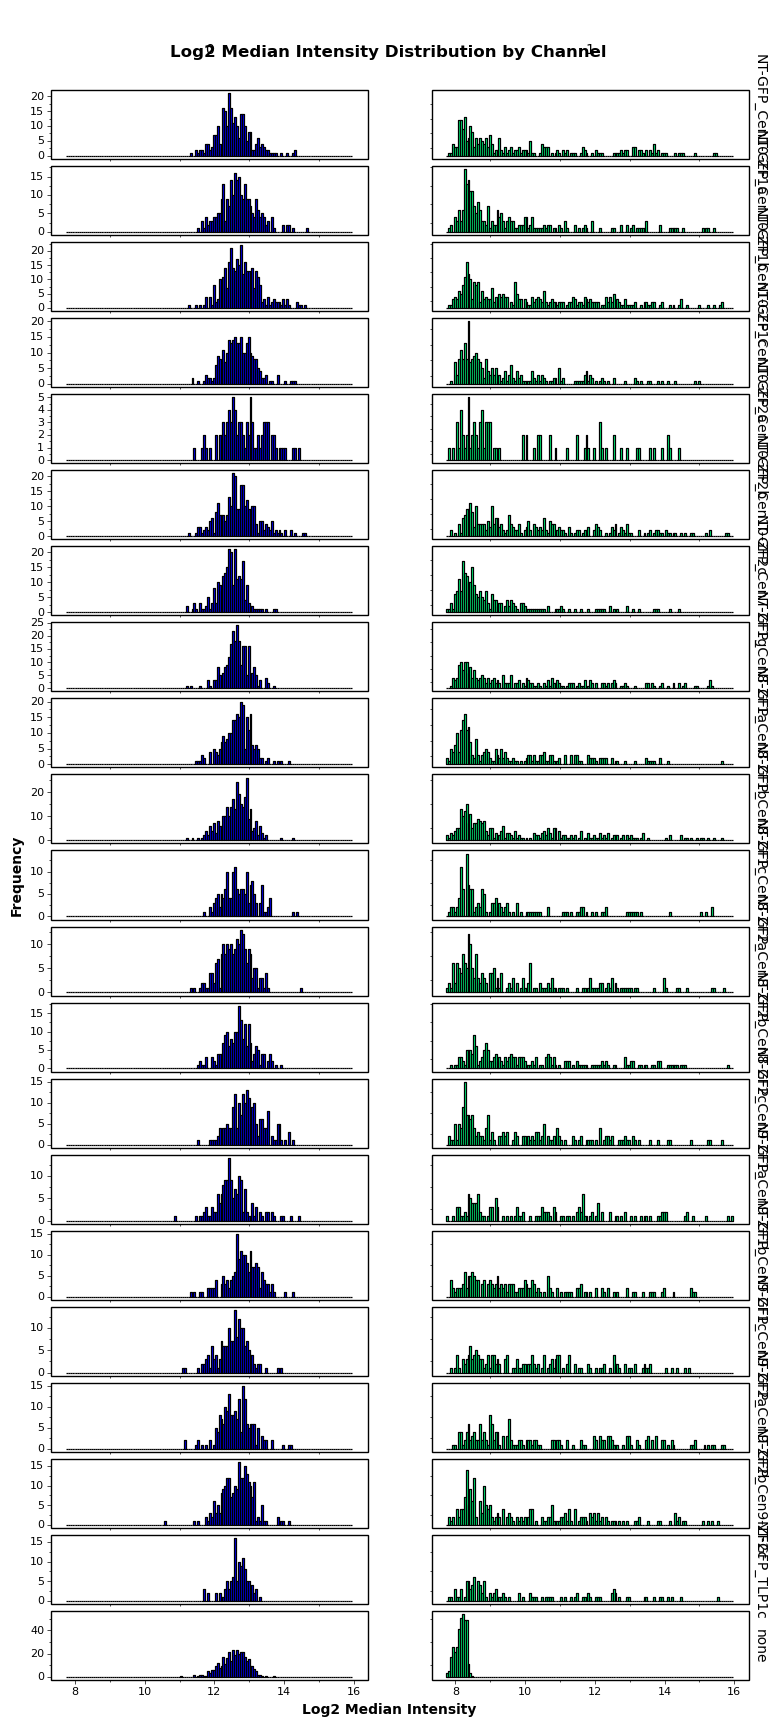

In [227]:
# Histograms
# Plot the values of Channel 0 (Hoechst) and Channel 1 (GFP) as histograms for each plasmid

# Assign colors to each channel
channel_colors = {0: 'blue', 1: 'springgreen'}

# Define plot using plotnine
plot = (
    p9.ggplot(data = combined_df) + 
    p9.aes(x = 'log2_median', fill = 'factor(channel)') +  # factor() to treat channel as categorical
    p9.geom_histogram(bins = 150, color = 'black') +
    p9.facet_grid('plasmid ~ channel', scales = 'free_y') +  # Create separate plots for each channel
    p9.scale_x_continuous(limits = (combined_df['log2_median'].min(), 
                                    combined_df['log2_median'].max())) +
    p9.scale_fill_manual(values = channel_colors) +
    p9.labs(title = 'Log2 Median Intensity Distribution by Channel',
            x = 'Log2 Median Intensity',
            y = 'Frequency') +
    p9.theme_bw() + 
    p9.theme(figure_size = (9, 6), # Adjust figure size
             aspect_ratio = 1/5,
             subplots_adjust = {'wspace': 0.20},  # Adjust space between plots
             legend_position = 'none',  # Hide legend if desired
             panel_grid = p9.element_blank(), 
             strip_background = p9.element_blank(), 
             panel_border = p9.element_rect(color = 'black', linewidth = 1), 
             axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
             plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
             axis_text = p9.element_text(size = 8, color = 'black'), 
             axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             legend_text = p9.element_text(size = 8, color = 'black'), 
             legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
             strip_text = p9.element_text(size = 10, color = 'black'))
)

# Print the plot
print(plot)

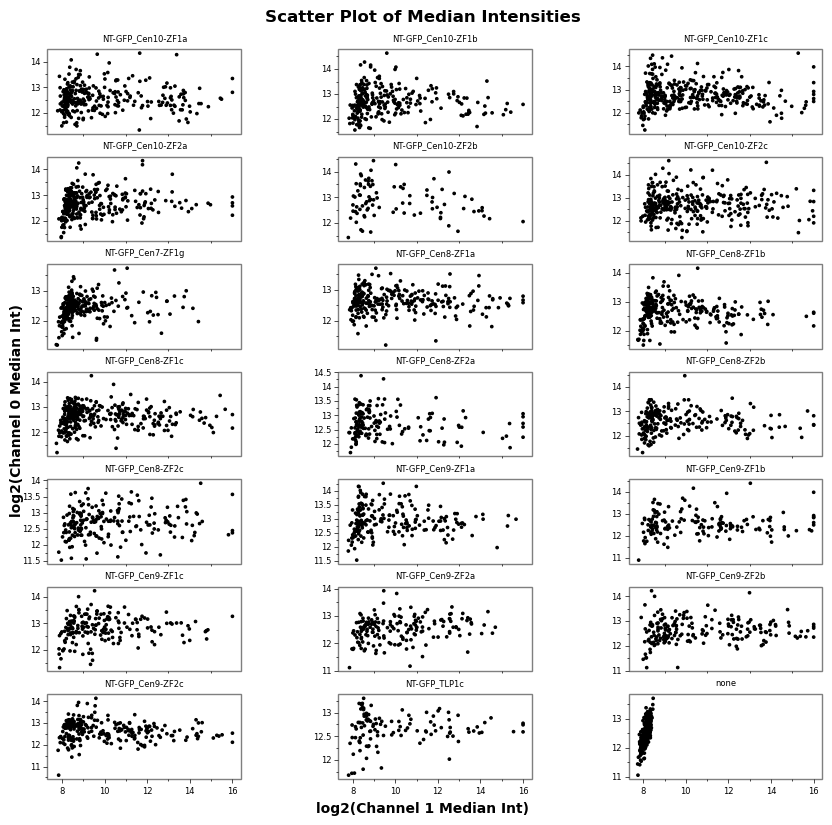

In [229]:
# Scatterplot

my_plasmids = ['none', 'NT-GFP_TLP1c', 'NT-GFP_Cen7-ZF1g']
my_data = wide_df[wide_df['plasmid'].isin(my_plasmids)]

# Plot Channel 0 vs Channel 1 as a scatter plot to separate clusters
plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'ch1_log2_median', 
                               y = 'ch0_log2_median')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5) +  # Add points for scatter plot
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'log2(Channel 1 Median Int)',
        y = 'log2(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid', scales = 'free_y', ncol = 3) +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (10, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        subplots_adjust = {'wspace': 0.50},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [231]:
# CHUNK 8
# Correct Channel 1 values

# There seems to be some sort of relationship between Channel 1 and Channel 0 that should not be there. 
# I will fit a linear model to the data of untransfected cells, and use the slope to correct Ch1 in all groups

import statsmodels.api as sm

# Filter for untransfected cells
utx = wide_df[wide_df['plasmid'] == 'none']

# Prepare the data for regression
X = utx['ch0_log2_median']  # Independent variable
X = sm.add_constant(X)  # Adds a constant term to the predictor
y = utx['ch1_log2_median']  # Dependent variable

# Fit the linear model
model = sm.OLS(y, X).fit()

# Get the slope (beta coefficient) and intercept
beta, intercept = model.params['ch0_log2_median'], model.params['const']

print("Model coefficients:")
print("Slope (beta):", beta)
print("Intercept:", intercept)

# Calculate the original range of Channel 1 values
or_min = wide_df['ch1_log2_median'].min()
or_max = wide_df['ch1_log2_median'].max()

# Correct CH1 values across the entire wide_df data frame
wide_df['cor_ch1_log2_median'] = wide_df['ch1_log2_median'] - (beta * wide_df['ch0_log2_median'])

# Calculate the range of the corrected values
cor_min = wide_df['cor_ch1_log2_median'].min()
cor_max = wide_df['cor_ch1_log2_median'].max()

# Rescale the corrected values to the original range
wide_df['cor_ch1_log2_median'] = (wide_df['cor_ch1_log2_median'] - cor_min) / (cor_max - cor_min) * (or_max - or_min) + or_min

Model coefficients:
Slope (beta): 0.2796691350533658
Intercept: 4.638091589474258


In [233]:
# Make a wide_bk_df data frame from bk_df

# Calculate the log2 of the chosen metric
bk_df['log2_median'] = np.log2(bk_df['median_intensity'] + 1)  # Adding 1 to avoid log2(0)

# Extract a subset of columns into a new data frame
wide_bk_df = bk_df[['image_index', 'channel', 'log2_median']]

# Pivot wide_df to get separate columns for each channel's log2_median
wide_bk_df = wide_bk_df.pivot_table(
    index = ['image_index'],  # Indices to group by
    columns = 'channel',  # Column to pivot
    values = 'log2_median',  # Values to fill with
    aggfunc = 'first'  # Using 'first' assuming each group-channel combo has a unique entry
).reset_index()

# Rename the pivoted columns to reflect the channel information
wide_bk_df.columns = [f"{col}_log2_median" if isinstance(col, int) else col for col in wide_bk_df.columns]
wide_bk_df.rename(columns = {
    '0_log2_median': 'ch0_log2_median',
    '1_log2_median': 'ch1_log2_median'
}, inplace = True)

wide_bk_df = pd.merge(wide_bk_df, wide_df[['image_index', 'plasmid']], on = "image_index", how = "left")

In [97]:
print(wide_bk_df.head())

   image_index  ch0_log2_median  ch1_log2_median           plasmid
0            0         9.941048         8.396605  NT-GFP_Cen3-ZF1b
1            0         9.941048         8.396605  NT-GFP_Cen3-ZF1b
2            0         9.941048         8.396605  NT-GFP_Cen3-ZF1b
3            0         9.941048         8.396605  NT-GFP_Cen3-ZF1b
4            0         9.941048         8.396605  NT-GFP_Cen3-ZF1b


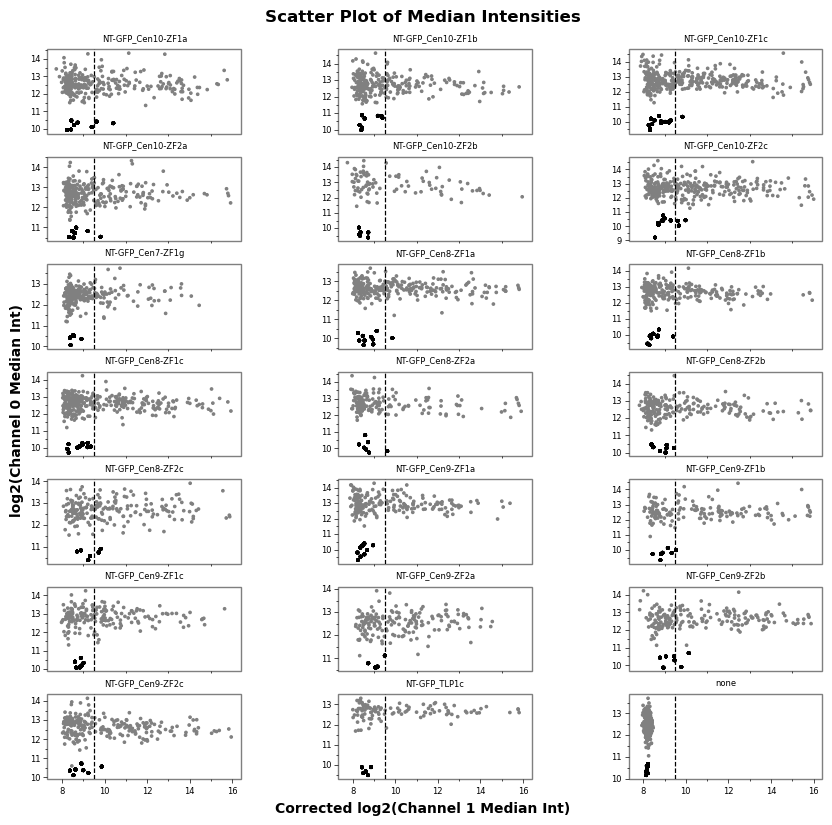

In [235]:
# Make the same scatterplot as above, using the corrected data
plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'cor_ch1_log2_median', 
                               y = 'ch0_log2_median')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5, color = 'gray') +  # Add points for scatter plot
    p9.geom_point(data = wide_bk_df, 
                  mapping = p9.aes(x = 'ch1_log2_median', 
                                   y = 'ch0_log2_median'), 
                  size = 0.5, color = 'black') + # Overlay points for the background data
    p9.geom_vline(xintercept = 9.5, linetype = 'dashed') + 
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'Corrected log2(Channel 1 Median Int)',
        y = 'log2(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid', scales = 'free_y', ncol = 3) +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.theme(
        figure_size = (10, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        subplots_adjust = {'wspace': 0.50},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [237]:
# Use a thresholding approach to classify cells according to GFP expression

# Define a conservative hard threshold
# my_threshold = 9.5

# Or define a threshold based on untransfected cells (115% of the median CH2 value)
utx_df = wide_df[wide_df['plasmid'] == 'none']
my_threshold = np.median(utx_df['ch1_log2_median']) * 1.15

# Apply threshold to classify cells
wide_df['tx_status_thr'] = np.where(wide_df['cor_ch1_log2_median'] <= my_threshold, "N", "Y")

In [239]:
# Use a Gaussian Mixture Model (GMM) to cluster cells as transfected or untransfected

from sklearn.mixture import GaussianMixture

# Reshape data for clustering
X = wide_df['cor_ch1_log2_median'].values.reshape(-1, 1)

# Fit a GMM with two components
gmm = GaussianMixture(n_components = 2, random_state = 0).fit(X)

# Predict the cluster each data point belongs to
wide_df['cluster'] = gmm.predict(X)

# Determine cluster labels based on the means of the Gaussian components
negative_lbl = 0 if gmm.means_[0] < gmm.means_[1] else 1

# Assign statuses based on clusters
wide_df['tx_status_gmm'] = np.where(wide_df['cluster'] == negative_lbl, "N", "Y")

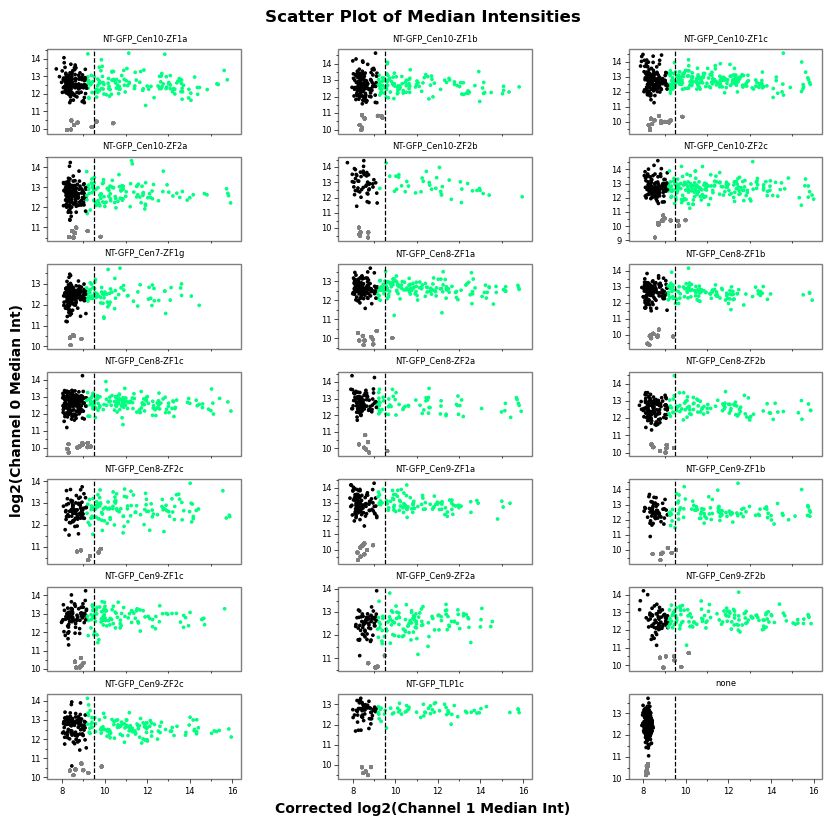

In [241]:
# Make the same scatterplot as above, coloring cells by group this time
group_colors = {"N": 'black', "Y": 'springgreen'}

plot = (
    p9.ggplot(data = wide_df, 
              mapping = p9.aes(x = 'cor_ch1_log2_median', 
                               y = 'ch0_log2_median', 
                               color = 'tx_status_gmm')) +  # Set aesthetic mappings
    p9.geom_point(size = 0.5) +  # Add points for scatter plot
    p9.geom_point(data = wide_bk_df, 
                  mapping = p9.aes(x = 'ch1_log2_median', 
                                   y = 'ch0_log2_median'), 
                  size = 0.5, color = 'gray') + # Overlay points for the background data
    p9.geom_vline(xintercept = 9.5, linetype = 'dashed') + 
    p9.labs(
        title = 'Scatter Plot of Median Intensities',
        x = 'Corrected log2(Channel 1 Median Int)',
        y = 'log2(Channel 0 Median Int)'
    ) + 
    p9.facet_wrap(' ~ plasmid', scales = 'free_y', ncol = 3) +  # Create separate plots for each channel
    p9.theme_bw() +  # Use a clean theme
    p9.scale_color_manual(values = group_colors) + 
    p9.theme(
        figure_size = (10, 6),  # Set the size of the plot
        aspect_ratio = 1/3,
        subplots_adjust = {'wspace': 0.50},  # Adjust space between plots
        panel_grid = p9.element_blank(),  # Hide grid lines
        legend_position = 'none',  # Hide legend if desired
        plot_background = p9.element_rect(fill='white'),  # Set background to white
        axis_ticks = p9.element_line(color = 'black', linewidth = 0.5), 
        plot_title = p9.element_text(size = 12, color = 'black', face = 'bold'),
        axis_text = p9.element_text(size = 6, color = 'black'), 
        axis_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        legend_text = p9.element_text(size = 6, color = 'black'), 
        legend_title = p9.element_text(size = 10, color = 'black', face = 'bold'), 
        strip_text = p9.element_text(size = 6, color = 'black'), 
        strip_background = p9.element_blank()
    )
)

# Print the plot
print(plot)

In [ ]:
# Test different parameter values

# Parameters to test
my_values = [0.001, 0.005, 0.01, 0.05, 0.1]  # Adjust with your values

# Select channel 2 for testing
channel = 1
image = my_image[channel]

# Number of subplots needed (one for each value in min_sigma_values)
num_subplots = len(my_values)

# Set up a large enough figure to hold all subplots
plt.figure(figsize=(15, 3 * num_subplots))

# Loop over each min_sigma value and perform blob detection
for idx, threshold_rep in enumerate(my_values):
    # Detect blobs
    blobs_log = feature.blob_log(image.astype(float), min_sigma=0.05, max_sigma=5, num_sigma=10, threshold_rel=threshold_rel)

    # Create a subplot for each min_sigma value
    plt.subplot(1, num_subplots, idx + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f'threshold_rel = {threshold_rel}')

    # Plot the blobs
    for blob in blobs_log:
        y, x, r = blob
        c = plt.Circle((x, y), r*500, color='red', linewidth=2, fill=False)
        plt.gca().add_patch(c)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Find spots in FISH channel

# Make a dictionary to store blob information per ROI
blobs_per_roi = {}

# fish_params: min_sigma = 0.05, max_sigma = 5, num_sigma = 10, threshold_rel = 0.3

# Iterate over each channel in 'my_image'
# looking for blobs
for channel_index in range(my_image.shape[0]):
    image = my_image[channel_index]

    # Detect blobs using Laplacian of Gaussian
    # Adjust these parameters as necessary for your data
    blobs_log = feature.blob_log(image.astype(float), 
                                 min_sigma = 0.05, 
                                 max_sigma = 5, 
                                 num_sigma = 10, 
                                 threshold_rel = 0.3)

    # Filter detected blobs to be within ROIs defined in my_nucmask
    for blob in blobs_log:
        y, x, r = blob  # Blob position and estimated radius
        roi_id = my_nucmask[int(y), int(x)]
        if roi_id != 0:  # Check if inside an ROI
            if roi_id not in blobs_per_roi:
                blobs_per_roi[roi_id] = []
            blobs_per_roi[roi_id].append((channel_index, x, y, r))



In [ ]:
# Visualize the result of FISH spot detection

# Select a channel to visualize, e.g., the first channel
selected_channel = 2
plt.figure(figsize=(10, 10))
plt.imshow(my_image[selected_channel], cmap='gray')

# Plot the blobs
for blob_info in blobs_per_roi.values():
    for blob in blob_info:
        channel, x, y, r = blob
        if channel == selected_channel:  # Only plot blobs for the selected channel
            c = plt.Circle((x, y), r*250, color='red', linewidth = 1, fill = False)
            plt.gca().add_patch(c)
            
plt.title(f'Blobs in Channel {selected_channel}')
plt.axis('off')
plt.show()

In [ ]:
# Try to find spots in IF channel using same parameters as for FISH channel (chunk above)

# Specified ROIs to focus on
selected_rois = [9, 10, 11, 14, 16, 17, 20, 26, 29]

# Parameters for blob detection (these work well for FISH, channel 2)
# min_sigma = 0.05
# max_sigma = 5
# num_sigma = 10
# threshold_rel = 0.3

# Parameters for blob detection (adjust these for channel 1)
min_sigma = 0.05
max_sigma = 5
num_sigma = 10

# Parameters to test
threshold_values = [0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3, 0.31, 0.32] # adjust as needed

# Set up a figure for subplots
n_cols = 3
n_rows = -(-len(threshold_values) // n_cols)  # Ceiling division to get number of rows
plt.figure(figsize=(15, 5 * n_rows))  # Adjust the size as needed

# Select channel 1 for blob detection
channel_index = 1
image = my_image[channel_index]

# Dictionary to store blob information for each ROI
blobs_per_roi = {}

# Iterate over each threshold_rel value
for i, threshold_rel in enumerate(threshold_values):
    # Detect blobs using Laplacian of Gaussian for the entire image
    blobs_log = feature.blob_log(image.astype(float), 
                                 min_sigma=min_sigma, 
                                 max_sigma=max_sigma, 
                                 num_sigma=num_sigma, 
                                 threshold_rel=threshold_rel)

    # Create a subplot for each threshold_rel value
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(image, cmap='gray')

    # Filter and plot blobs for selected ROIs
    for blob in blobs_log:
        y, x, r = blob
        roi_id = my_nucmask[int(y), int(x)]
        if roi_id in selected_rois:
            c = plt.Circle((x, y), r*250, color='red', linewidth=1, fill=False)
            plt.gca().add_patch(c)

    plt.title(f'threshold_rel = {threshold_rel}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Assuming 'my_image' and 'my_nucmask' are defined
channel = 1
image = my_image[channel]

# Specified ROIs to focus on
selected_rois = [9, 10, 11, 14, 16, 17, 20, 26, 29]

# Parameters for blob detection (adjust these for channel 1)
min_sigma = 0.05
max_sigma = 5
num_sigma = 10

# After testing with the script in the previous chunk, 
# I find that the following threshold_rel values are best for the given mean intensities
known_intensities = [900, 1200, 1500, 2200, 2800]
known_thresholds = [0.096, 0.125, 0.19, 0.24, 0.285]

# Fit a quadratic polynomial (degree 2) to known data
coefficients = np.polyfit(known_intensities, known_thresholds, 2)
polynomial = np.poly1d(coefficients)

# Make a dictionary to store blob information per ROI
blobs_per_roi = {}

# Detect blobs using Laplacian of Gaussian for the entire image
threshold_rel_avg = np.mean([polynomial(np.mean(image[my_nucmask == roi_id])) for roi_id in selected_rois])
blobs_log = feature.blob_log(image.astype(float), 
                             min_sigma = min_sigma, 
                             max_sigma = max_sigma, 
                             num_sigma = num_sigma, 
                             threshold_rel=threshold_rel_avg)

# Filter detected blobs to be within the selected ROIs
for blob in blobs_log:
    y, x, r = blob
    roi_id = my_nucmask[int(y), int(x)]
    if roi_id in selected_rois:
        if roi_id not in blobs_per_roi:
            blobs_per_roi[roi_id] = []
        blobs_per_roi[roi_id].append((x, y, r))

# Visualization
plt.figure(figsize=(10, 10))
plt.imshow(image, cmap='gray')
for roi_id, blobs in blobs_per_roi.items():
    for x, y, r in blobs:
        c = plt.Circle((x, y), r * 250, color='red', linewidth=1, fill=False)
        plt.gca().add_patch(c)
plt.axis('off')
plt.title('Detected Blobs in Channel 1')
plt.show()